<a href="https://colab.research.google.com/github/ladylaura22/Deteccion_de_fraude_bancario/blob/main/Act2Detecci%C3%B3n_de_Fraude_en_Transacciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**S25 - Módulo 2. Actividad didáctica 2 Modelos Ocultos de Markov (HMM)**

**Profesor:**

**Julian Andres Loaiza Lopez**

**Simulación - PREICA2601B020049**

**Integrantes del grupo:**
- Lady Laura Olmos Contreras
- Juan Felipe Parra Palacios
- Jorge Andrés Hernández Campos


**IU Dgital de Antioquia**

**5/16/2026**





# Modelo Oculto de Markov — Detección de Fraude en Transacciones
**Distribuciones de Probabilidad · Semana 4**

Simula un HMM para detectar fraude financiero.
Los **estados ocultos** son: Legítima · Sospechosa · Fraudulenta.
Las **observaciones** son los montos categorizados: Bajo · Medio · Alto.

> **Nota sobre la semilla en `scoring_riesgo`:** El ruido `±10` simula variabilidad real (contexto, hora, comportamiento). En producción no se usaría semilla. En este notebook académico se fija para que todos los resultados sean reproducibles y coherentes con la simulación fija de `simular()` y `generar_montos()`.

## 1 · Importaciones

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# Semilla global del experimento — cambia este valor para explorar distintos escenarios
SEMILLA = 2024
T = 5000  # número de transacciones a simular

## 2 · Definición del modelo

Los tres componentes del HMM:
- **π** — probabilidad de comenzar en cada estado
- **A** — probabilidad de pasar de un estado a otro (transición)
- **B** — probabilidad de observar un monto dado el estado (emisión)

In [ ]:
# Estados ocultos (el "mundo real" que no vemos directamente)
ESTADOS = ['Legítima', 'Sospechosa', 'Fraudulenta']
N_ESTADOS = len(ESTADOS)

# Observaciones (lo que sí vemos: el monto de la transacción)
OBSERVACIONES = ['Monto Bajo', 'Monto Medio', 'Monto Alto']
N_OBS = len(OBSERVACIONES)

# π: distribución inicial
pi = np.array([0.70, 0.20, 0.10])

# A[i][j] = P(pasar al estado j | estar en estado i)
A = np.array([
    [0.80, 0.15, 0.05],   # Desde Legítima
    [0.40, 0.40, 0.20],   # Desde Sospechosa
    [0.10, 0.30, 0.60],   # Desde Fraudulenta
])

# B[i][k] = P(observar monto k | estar en estado i)
B = np.array([
    [0.60, 0.30, 0.10],   # Legítima   emite montos
    [0.30, 0.40, 0.30],   # Sospechosa emite montos
    [0.10, 0.30, 0.60],   # Fraudulenta emite montos
])

# Verificación: cada fila debe sumar exactamente 1.0
assert np.allclose(pi.sum(), 1.0),        "π no suma 1"
assert np.allclose(A.sum(axis=1), 1.0),   "Alguna fila de A no suma 1"
assert np.allclose(B.sum(axis=1), 1.0),   "Alguna fila de B no suma 1"
print("✅ Matrices validadas correctamente.")

✅ Matrices validadas correctamente.


## 3 · Clase HMMFraude

Encapsula toda la lógica del modelo:
- `simular()` — genera una secuencia de transacciones
- `viterbi()` — infiere los estados más probables dadas las observaciones
- `scoring_riesgo()` — asigna un puntaje 0–100 por transacción
- `generar_montos()` — convierte categorías en montos reales en USD
- `calcular_metricas()` — métricas de negocio
- `metricas_clasificacion()` — Precisión, Recall y F1 por clase *(nuevo)*

In [ ]:
class HMMFraude:
    """
    Modelo Oculto de Markov para detección de fraude financiero.

    Parámetros
    ----------
    pi     : distribución inicial (N,)
    A      : matriz de transición (N x N)
    B      : matriz de emisión (N x M)
    estados       : nombres de los estados ocultos
    observaciones : nombres de las observaciones
    """

    def __init__(self, pi, A, B, estados, observaciones):
        self.pi = pi
        self.A  = A
        self.B  = B
        self.estados      = estados
        self.observaciones = observaciones
        self.N = len(estados)
        self.M = len(observaciones)

    # 3.1 Simulación
    def simular(self, T, semilla=None):
        """
        Genera una secuencia de T transacciones.
        Retorna los índices de estados ocultos y observaciones.
        """
        rng = np.random.default_rng(semilla)
        estados_seq = np.zeros(T, dtype=int)
        obs_seq     = np.zeros(T, dtype=int)

        estados_seq[0] = rng.choice(self.N, p=self.pi)
        obs_seq[0]     = rng.choice(self.M, p=self.B[estados_seq[0]])

        for t in range(1, T):
            estados_seq[t] = rng.choice(self.N, p=self.A[estados_seq[t-1]])
            obs_seq[t]     = rng.choice(self.M, p=self.B[estados_seq[t]])

        return estados_seq, obs_seq

    # 3.2 Algoritmo de Viterbi
    def viterbi(self, obs_seq):
        """
        Infiere la secuencia de estados más probable (decodificación).

        Usa programación dinámica:
        delta[t][j] = máxima probabilidad de llegar al estado j en el paso t.
        psi[t][j]   = estado previo que maximizó delta[t][j].
        """
        T = len(obs_seq)
        delta = np.zeros((T, self.N))
        psi   = np.zeros((T, self.N), dtype=int)

        # Inicialización
        delta[0] = self.pi * self.B[:, obs_seq[0]]

        # Recursión hacia adelante
        for t in range(1, T):
            for j in range(self.N):
                trans      = delta[t-1] * self.A[:, j]
                psi[t, j]  = np.argmax(trans)
                delta[t, j] = np.max(trans) * self.B[j, obs_seq[t]]

        # Retroceso (backtracking)
        mejor_seq = np.zeros(T, dtype=int)
        mejor_seq[-1] = np.argmax(delta[-1])
        for t in range(T-2, -1, -1):
            mejor_seq[t] = psi[t+1, mejor_seq[t+1]]

        return mejor_seq

    # 3.3 Score de riesgo
    def scoring_riesgo(self, estados_seq, semilla=None):
        """
        Asigna un score de riesgo 0–100 por transacción.

        Puntaje base por estado:
          Legítima    → ~15  (rango 5–25)
          Sospechosa  → ~45  (rango 35–55)
          Fraudulenta → ~85  (rango 75–95)

        CORRECCIÓN: se usa np.random.default_rng(semilla) en lugar del
        generador global np.random, para ser consistente con el resto del
        modelo y garantizar reproducibilidad cuando se pasa una semilla.
        """
        rng   = np.random.default_rng(semilla)
        pesos = {0: 15, 1: 45, 2: 85}
        ruido  = rng.uniform(-10, 10, len(estados_seq))
        scores = np.array([pesos[e] for e in estados_seq], dtype=float) + ruido
        return np.clip(scores, 0, 100)

    # 3.4 Montos en USD
    def generar_montos(self, obs_seq, semilla=None):
        """
        Convierte la categoría observada en un monto real en USD.
        Bajo: $10–$100 | Medio: $100–$1,000 | Alto: $1,000–$10,000
        """
        rng = np.random.default_rng(semilla)
        rangos = {0: (10, 100), 1: (100, 1_000), 2: (1_000, 10_000)}
        return np.array([round(rng.uniform(*rangos[o]), 2) for o in obs_seq])

    # 3.5 Métricas de negocio
    def calcular_metricas(self, estados_seq, montos):
        """Métricas operativas: conteos, montos en riesgo, tiempos."""
        T = len(estados_seq)
        n_leg = np.sum(estados_seq == 0)
        n_sos = np.sum(estados_seq == 1)
        n_fra = np.sum(estados_seq == 2)

        idx_fraude = np.where(estados_seq == 2)[0]
        tiempo_prom = np.diff(idx_fraude).mean() if len(idx_fraude) > 1 else None

        return {
            'total'            : T,
            'n_legitimas'      : n_leg,
            'n_sospechosas'    : n_sos,
            'n_fraudulentas'   : n_fra,
            'tasa_fraude'      : n_fra / T * 100,
            'tasa_sospecha'    : n_sos / T * 100,
            'monto_fraude'     : montos[estados_seq == 2].sum(),
            'monto_en_riesgo'  : montos[estados_seq >= 1].sum(),
            'tiempo_prom_fraude': tiempo_prom,
        }

    # 3.6 Métricas de clasificación ML
    def metricas_clasificacion(self, reales, inferidos):
        """
        Calcula Precisión, Recall y F1-score por clase.

        Compara los estados reales (de la simulación) con los estados
        inferidos por Viterbi. Permite evaluar qué tan bien funciona
        el algoritmo de decodificación.

        Fórmulas:
          Precisión = TP / (TP + FP)  → de los que marqué como X, ¿cuántos eran X?
          Recall    = TP / (TP + FN)  → de los que eran X, ¿cuántos detecté?
          F1        = 2 * P * R / (P + R)
        """
        resultados = {}
        for i, nombre in enumerate(self.estados):
            TP = np.sum((reales == i) & (inferidos == i))
            FP = np.sum((reales != i) & (inferidos == i))
            FN = np.sum((reales == i) & (inferidos != i))

            precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
            recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
            f1        = (2 * precision * recall / (precision + recall)
                         if (precision + recall) > 0 else 0.0)

            resultados[nombre] = {
                'TP': int(TP), 'FP': int(FP), 'FN': int(FN),
                'precision': round(precision, 3),
                'recall'   : round(recall, 3),
                'f1'       : round(f1, 3),
            }
        return resultados

## 4 · Simulación

In [ ]:
modelo = HMMFraude(pi, A, B, ESTADOS, OBSERVACIONES)

# Simulación: genera estados ocultos y observaciones
estados_seq, obs_seq = modelo.simular(T, semilla=SEMILLA)

# Viterbi: infiere estados a partir de las observaciones
estados_viterbi = modelo.viterbi(obs_seq)

# Montos y scores — misma semilla para coherencia total
montos  = modelo.generar_montos(obs_seq, semilla=SEMILLA)
scores  = modelo.scoring_riesgo(estados_seq, semilla=SEMILLA)   # semilla unificada

metricas       = modelo.calcular_metricas(estados_seq, montos)
met_clasif     = modelo.metricas_clasificacion(estados_seq, estados_viterbi)
accuracy_vitb  = np.mean(estados_viterbi == estados_seq) * 100

print("Simulación completada.")

Simulación completada.


## 5 · Resultados por transacción

In [ ]:
print("=" * 65)
print("   MODELO OCULTO DE MARKOV — DETECCIÓN DE FRAUDE")
print("=" * 65)
print(f"{'#':>3}  {'Estado Real':<14} {'Observación':<14} {'Monto (USD)':>12}  {'Score':>5}  Alerta")
print("-" * 65)

for t in range(T):
    e   = estados_seq[t]
    obs = OBSERVACIONES[obs_seq[t]]
    alerta = "🔴 FRAUDE" if e == 2 else "🟡 Sospechosa" if e == 1 else ""
    print(f"{t+1:>3}  {ESTADOS[e]:<14} {obs:<14} \${montos[t]:>11,.2f}  {scores[t]:>5.1f}  {alerta}")

print()
print("=" * 65)
print("   MÉTRICAS DE NEGOCIO")
print("=" * 65)
m = metricas
print(f"  Transacciones totales      : {m['total']}")
print(f"  Legítimas                  : {m['n_legitimas']}  ({100*m['n_legitimas']/m['total']:.1f}%)")
print(f"  Sospechosas                : {m['n_sospechosas']}  ({m['tasa_sospecha']:.1f}%)")
print(f"  Fraudulentas               : {m['n_fraudulentas']}  ({m['tasa_fraude']:.1f}%)")
print(f"  Monto en riesgo (fra+sos)  : \${m['monto_en_riesgo']:,.2f}")
print(f"  Monto solo fraudes         : \${m['monto_fraude']:,.2f}")
if m['tiempo_prom_fraude']:
    print(f"  Tiempo prom. entre fraudes : {m['tiempo_prom_fraude']:.1f} transacciones")

print()
print("=" * 65)
print("   MÉTRICAS DE CLASIFICACIÓN — VITERBI vs REAL  (NUEVO)")
print("=" * 65)
print(f"  Accuracy global Viterbi    : {accuracy_vitb:.1f}%")
print()
print(f"  {'Estado':<14} {'Precisión':>10} {'Recall':>8} {'F1':>8} {'TP':>5} {'FP':>5} {'FN':>5}")
print(f"  {'-'*56}")
for estado, v in met_clasif.items():
    print(f"  {estado:<14} {v['precision']:>10.3f} {v['recall']:>8.3f} {v['f1']:>8.3f} {v['TP']:>5} {v['FP']:>5} {v['FN']:>5}")
print("=" * 65)

   MODELO OCULTO DE MARKOV — DETECCIÓN DE FRAUDE
  #  Estado Real    Observación     Monto (USD)  Score  Alerta
-----------------------------------------------------------------
  1  Legítima       Monto Bajo     \$      70.82   18.5  
  2  Legítima       Monto Medio    \$     292.89    9.3  
  3  Fraudulenta    Monto Medio    \$     378.51   81.2  🔴 FRAUDE
  4  Legítima       Monto Bajo     \$      81.95   21.0  
  5  Legítima       Monto Bajo     \$      99.62   24.9  
  6  Legítima       Monto Medio    \$     228.01    7.8  
  7  Legítima       Monto Bajo     \$      17.09    6.6  
  8  Legítima       Monto Bajo     \$      26.27    8.6  
  9  Fraudulenta    Monto Alto     \$   4,236.82   82.2  🔴 FRAUDE
 10  Fraudulenta    Monto Medio    \$     252.66   78.4  🔴 FRAUDE
 11  Sospechosa     Monto Medio    \$     629.88   46.8  🟡 Sospechosa
 12  Legítima       Monto Medio    \$     655.13   17.3  
 13  Legítima       Monto Bajo     \$      19.48    7.1  
 14  Sospechosa     Monto Bajo  

<>:11: SyntaxWarning: invalid escape sequence '\$'
<>:22: SyntaxWarning: invalid escape sequence '\$'
<>:23: SyntaxWarning: invalid escape sequence '\$'
<>:11: SyntaxWarning: invalid escape sequence '\$'
<>:22: SyntaxWarning: invalid escape sequence '\$'
<>:23: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_42070/4146247182.py:11: SyntaxWarning: invalid escape sequence '\$'
  print(f"{t+1:>3}  {ESTADOS[e]:<14} {obs:<14} \${montos[t]:>11,.2f}  {scores[t]:>5.1f}  {alerta}")
/tmp/ipykernel_42070/4146247182.py:22: SyntaxWarning: invalid escape sequence '\$'
  print(f"  Monto en riesgo (fra+sos)  : \${m['monto_en_riesgo']:,.2f}")
/tmp/ipykernel_42070/4146247182.py:23: SyntaxWarning: invalid escape sequence '\$'
  print(f"  Monto solo fraudes         : \${m['monto_fraude']:,.2f}")


Bloque 1: Cálculo de las Probabilidades Teóricas (Distribución Estacionaria)Este bloque utiliza álgebra lineal para calcular las probabilidades exactas hacia las que debería converger el modelo según tu matriz de transición ($A$).

In [ ]:
# -------------------------------------------------------------------------
# BLOQUE 1: CÁLCULO DE LA DISTRIBUCIÓN TEÓRICA (ESTACIONARIA)
# -------------------------------------------------------------------------
import scipy.linalg as la
import pandas as pd

def calcular_distribucion_estacionaria(A):
    """Calcula la distribución estacionaria teórica de la matriz de transición A."""
    # Buscamos el autovector izquierdo correspondiente al autovalor 1
    evals, evecs = la.eig(A, left=True, right=False)
    # Encontramos el índice del autovalor más cercano a 1
    idx = np.argmin(np.abs(evals - 1.0))
    estacionaria = evecs[:, idx].real
    # Normalizamos para que la suma sea 1
    estacionaria = estacionaria / np.sum(estacionaria)
    return estacionaria

# Calculamos la teórica usando la matriz A previamente definida
dist_teorica = calcular_distribucion_estacionaria(A)

print("✅ PROBABILIDADES TEÓRICAS (Límite matemático del modelo):")
for i, estado in enumerate(ESTADOS):
    print(f" - {estado}: {dist_teorica[i]*100:.2f}%")

✅ PROBABILIDADES TEÓRICAS (Límite matemático del modelo):
 - Legítima: 57.14%
 - Sospechosa: 23.81%
 - Fraudulenta: 19.05%


Bloque 2: Ejecución de Múltiples Simulaciones Incrementales (Tabla de Resultados)
Para cumplir con la rúbrica ("Presenta tablas claras"), vamos a correr la simulación con diferentes tamaños de secuencia (desde 100 hasta 100,000 transacciones) y tabular cómo las frecuencias empíricas se van acercando a las teóricas.

In [ ]:
# -------------------------------------------------------------------------
# BLOQUE 2: SIMULACIONES PARA DEMOSTRAR CONVERGENCIA (TABLA)
# -------------------------------------------------------------------------
# Tamaños de simulación a evaluar
tamanos_T = [100, 500, 1000, 5000, 10000, 50000, 100000]

# Listas para almacenar las probabilidades empíricas
empiricas_legitima = []
empiricas_sospechosa = []
empiricas_fraudulenta = []

print("Ejecutando simulaciones incrementales para evaluar convergencia...")

for t_val in tamanos_T:
    # Simulamos usando el método de tu clase
    estados_seq, _ = modelo.simular(t_val, semilla=SEMILLA)

    # Conteo empírico de los estados en esta simulación
    conteo = np.bincount(estados_seq, minlength=3)
    prob_empirica = conteo / t_val

    empiricas_legitima.append(prob_empirica[0])
    empiricas_sospechosa.append(prob_empirica[1])
    empiricas_fraudulenta.append(prob_empirica[2])

# Construcción de tabla de presentación de resultados (Requisito de Rúbrica)
df_convergencia = pd.DataFrame({
    'Iteraciones (T)': tamanos_T,
    'P(Legítima) Empírica': [f"{p*100:.2f}%" for p in empiricas_legitima],
    'P(Sospechosa) Empírica': [f"{p*100:.2f}%" for p in empiricas_sospechosa],
    'P(Fraudulenta) Empírica': [f"{p*100:.2f}%" for p in empiricas_fraudulenta]
})

print("\n📊 TABLA DE CONVERGENCIA EMPÍRICA:")
display(df_convergencia)

Ejecutando simulaciones incrementales para evaluar convergencia...

📊 TABLA DE CONVERGENCIA EMPÍRICA:


,Iteraciones (T),P(Legítima) Empírica,P(Sospechosa) Empírica,P(Fraudulenta) Empírica
0,100,56.00%,27.00%,17.00%
1,500,49.20%,27.60%,23.20%
2,1000,52.10%,25.90%,22.00%
3,5000,56.30%,23.36%,20.34%
4,10000,57.68%,23.15%,19.17%
5,50000,57.84%,23.47%,18.69%
6,100000,57.56%,23.62%,18.82%


Bloque 3: Visualización Gráfica de la Convergencia (Gráficos Claros)
La rúbrica exige "gráficos o salidas relevantes que evidencien el comportamiento". Este gráfico demostrará visualmente que, gracias a la Ley de los Grandes Números, el comportamiento aleatorio converge a la perfección matemática de tus matrices.

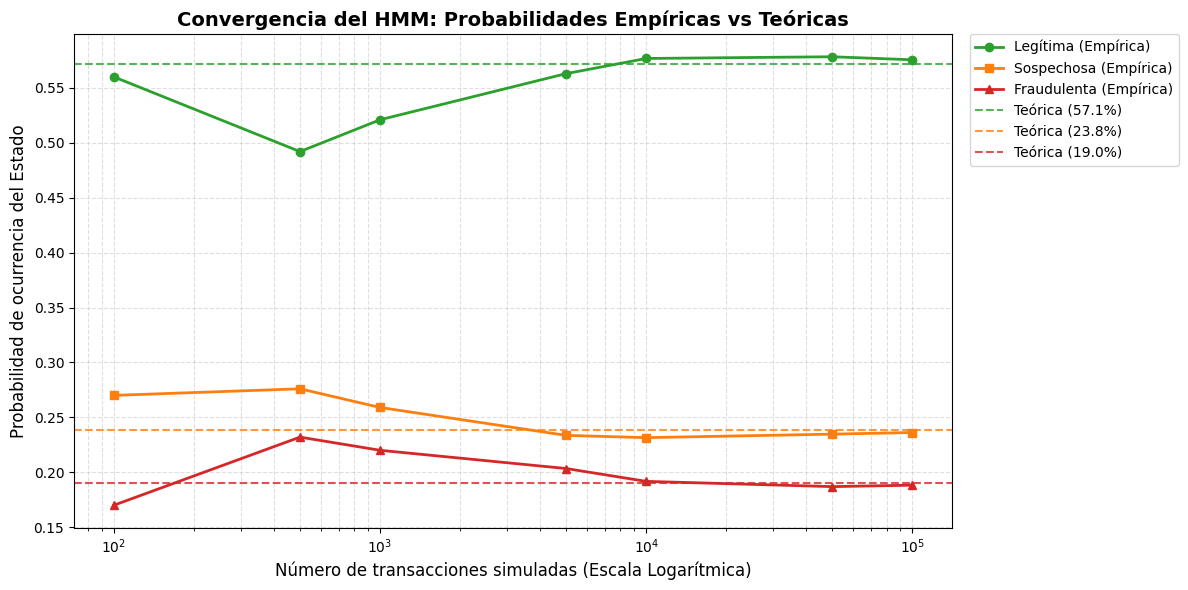

✅ Gráfico guardado exitosamente. Sube 'convergencia_hmm.png' a tu repositorio de GitHub como evidencia.


In [ ]:
# -------------------------------------------------------------------------
# BLOQUE 3: VISUALIZACIÓN GRÁFICA DE LA CONVERGENCIA (HMM)
# -------------------------------------------------------------------------
plt.figure(figsize=(12, 6))

# Trazar la evolución empírica (Líneas sólidas con puntos)
plt.plot(tamanos_T, empiricas_legitima, marker='o', label='Legítima (Empírica)', color='#2ca02c', linewidth=2)
plt.plot(tamanos_T, empiricas_sospechosa, marker='s', label='Sospechosa (Empírica)', color='#ff7f0e', linewidth=2)
plt.plot(tamanos_T, empiricas_fraudulenta, marker='^', label='Fraudulenta (Empírica)', color='#d62728', linewidth=2)

# Trazar las líneas de tendencia teórica (Líneas punteadas)
plt.axhline(y=dist_teorica[0], color='#2ca02c', linestyle='--', alpha=0.8, label=f'Teórica ({dist_teorica[0]*100:.1f}%)')
plt.axhline(y=dist_teorica[1], color='#ff7f0e', linestyle='--', alpha=0.8, label=f'Teórica ({dist_teorica[1]*100:.1f}%)')
plt.axhline(y=dist_teorica[2], color='#d62728', linestyle='--', alpha=0.8, label=f'Teórica ({dist_teorica[2]*100:.1f}%)')

# Configuración del gráfico
plt.xscale('log') # Escala logarítmica para evidenciar el comportamiento asintótico
plt.title('Convergencia del HMM: Probabilidades Empíricas vs Teóricas', fontsize=14, fontweight='bold')
plt.xlabel('Número de transacciones simuladas (Escala Logarítmica)', fontsize=12)
plt.ylabel('Probabilidad de ocurrencia del Estado', fontsize=12)

# Organizar leyenda afuera para que no tape los datos
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()

# Guardar la imagen para subir al repo (Cumplimiento repositorio GitHub)
plt.savefig('convergencia_hmm.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado exitosamente. Sube 'convergencia_hmm.png' a tu repositorio de GitHub como evidencia.")

## 6 · Dashboard visual

Cuatro gráficos en un solo panel:
1. **Timeline** de estados por transacción
2. **Montos** en escala logarítmica con umbrales
3. **Score de riesgo** con líneas de alerta
4. **Distribución** de estados (pie chart)

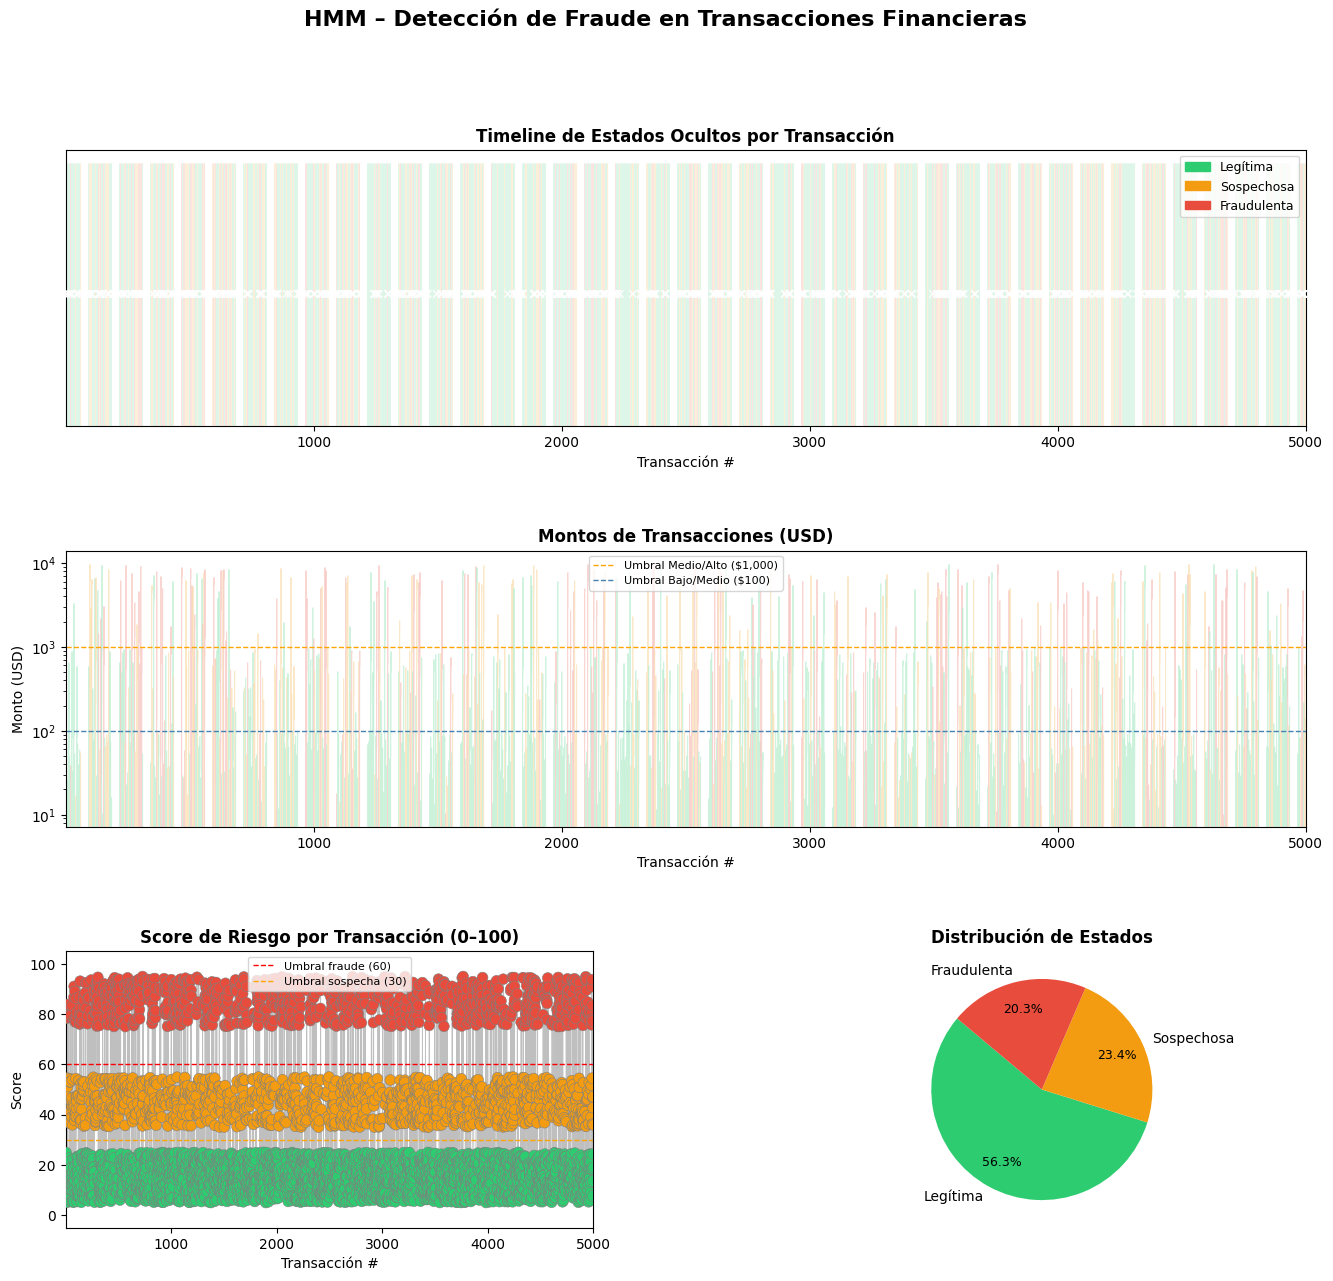

Dashboard guardado como 'hmm_fraude_dashboard.png'


In [ ]:
COLORES = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
t_arr   = np.arange(1, T + 1)

fig = plt.figure(figsize=(16, 14))
fig.suptitle('HMM – Detección de Fraude en Transacciones Financieras',
             fontsize=16, fontweight='bold', y=0.98)
gs = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# 6.1 Timeline de estados
ax1 = fig.add_subplot(gs[0, :])
ax1.bar(t_arr, np.ones(T), color=[COLORES[e] for e in estados_seq],
        edgecolor='white', linewidth=0.5)
for t in range(T):
    if estados_seq[t] == 2:
        ax1.text(t+1, 0.5, '✕', ha='center', va='center',
                 fontsize=10, color='white', fontweight='bold')
ax1.set_title('Timeline de Estados Ocultos por Transacción', fontweight='bold')
ax1.set_xlabel('Transacción #')
ax1.set_yticks([])
ax1.set_xlim(0.5, T + 0.5)
ax1.legend(handles=[mpatches.Patch(color=COLORES[i], label=ESTADOS[i])
                    for i in range(N_ESTADOS)], loc='upper right', fontsize=9)

# 6.2 Montos
ax2 = fig.add_subplot(gs[1, :])
ax2.bar(t_arr, montos, color=[COLORES[e] for e in estados_seq],
        edgecolor='white', linewidth=0.4, alpha=0.85)
ax2.axhline(y=1000, color='orange',    linestyle='--', linewidth=1, label='Umbral Medio/Alto ($1,000)')
ax2.axhline(y=100,  color='steelblue', linestyle='--', linewidth=1, label='Umbral Bajo/Medio ($100)')
ax2.set_title('Montos de Transacciones (USD)', fontweight='bold')
ax2.set_xlabel('Transacción #')
ax2.set_ylabel('Monto (USD)')
ax2.set_yscale('log')
ax2.legend(fontsize=8)
ax2.set_xlim(0.5, T + 0.5)

# 6.3 Score de riesgo
ax3 = fig.add_subplot(gs[2, 0])
ax3.scatter(t_arr, scores, c=[COLORES[e] for e in estados_seq],
            s=60, zorder=3, edgecolors='grey', linewidths=0.4)
ax3.plot(t_arr, scores, color='grey', linewidth=0.6, alpha=0.5)
ax3.axhline(y=60, color='red',    linestyle='--', linewidth=1, label='Umbral fraude (60)')
ax3.axhline(y=30, color='orange', linestyle='--', linewidth=1, label='Umbral sospecha (30)')
ax3.set_title('Score de Riesgo por Transacción (0–100)', fontweight='bold')
ax3.set_xlabel('Transacción #')
ax3.set_ylabel('Score')
ax3.legend(fontsize=8)
ax3.set_ylim(-5, 105)
ax3.set_xlim(0.5, T + 0.5)

# 6.4 Distribución
ax4 = fig.add_subplot(gs[2, 1])
conteos = [metricas['n_legitimas'], metricas['n_sospechosas'], metricas['n_fraudulentas']]
wedges, texts, autotexts = ax4.pie(
    conteos, labels=ESTADOS, colors=[COLORES[i] for i in range(3)],
    autopct='%1.1f%%', startangle=140, pctdistance=0.75)
for at in autotexts:
    at.set_fontsize(9)
ax4.set_title('Distribución de Estados', fontweight='bold')

plt.savefig('hmm_fraude_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard guardado como 'hmm_fraude_dashboard.png'")

## 7 · Comparación: Estados Reales vs Viterbi

El **algoritmo de Viterbi** encuentra la secuencia de estados ocultos más probable
dado lo que observamos (los montos). Esta comparación muestra qué tan bien funciona.

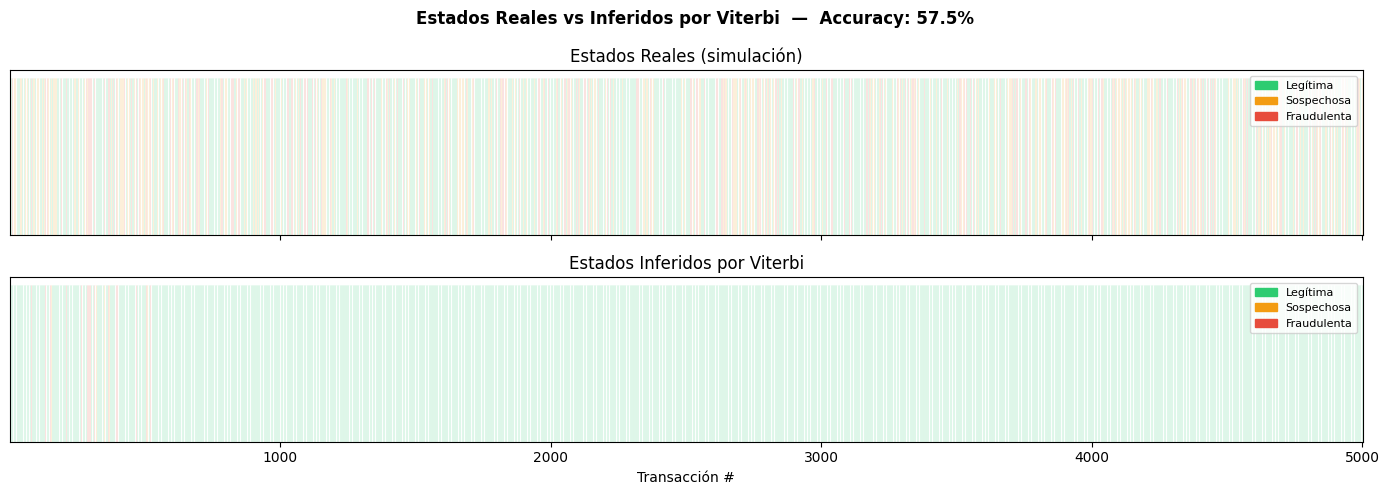

Gráfico guardado como 'hmm_fraude_viterbi.png'


In [ ]:
fig2, (ax_r, ax_v) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
fig2.suptitle(f'Estados Reales vs Inferidos por Viterbi  —  Accuracy: {accuracy_vitb:.1f}%',
              fontweight='bold')

for ax, seq, titulo in [
    (ax_r, estados_seq,     'Estados Reales (simulación)'),
    (ax_v, estados_viterbi, 'Estados Inferidos por Viterbi'),
]:
    ax.bar(t_arr, np.ones(T), color=[COLORES[e] for e in seq],
           edgecolor='white', linewidth=0.5)
    ax.set_title(titulo)
    ax.set_yticks([])
    ax.set_xlim(0.5, T + 0.5)
    ax.legend(handles=[mpatches.Patch(color=COLORES[i], label=ESTADOS[i])
                       for i in range(N_ESTADOS)], loc='upper right', fontsize=8)

ax_v.set_xlabel('Transacción #')
plt.tight_layout()
plt.savefig('hmm_fraude_viterbi.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Gráfico guardado como 'hmm_fraude_viterbi.png'")

## 8 · Heatmaps de las Matrices del Modelo

Visualización de **A** (transición) y **B** (emisión).
Los colores más intensos indican probabilidades más altas.

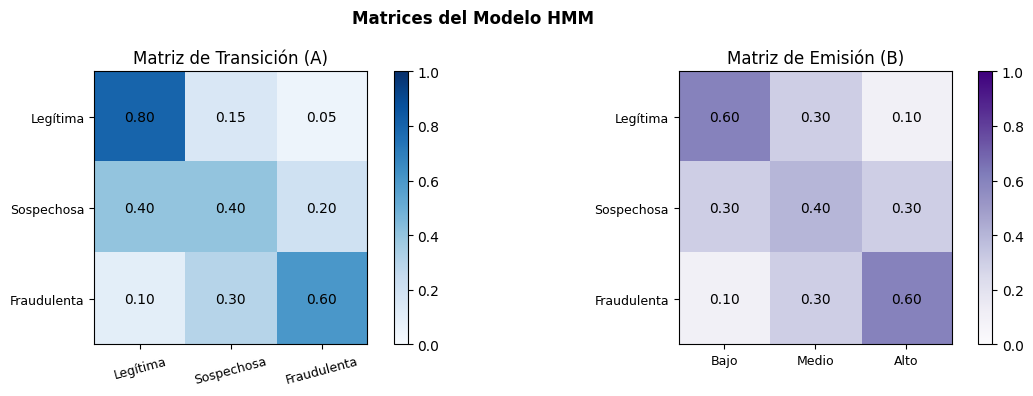

Matrices guardadas como 'hmm_fraude_matrices.png'


In [ ]:
fig3, (ax_A, ax_B) = plt.subplots(1, 2, figsize=(12, 4))
fig3.suptitle('Matrices del Modelo HMM', fontweight='bold')

# Matriz A
im_A = ax_A.imshow(A, cmap='Blues', vmin=0, vmax=1)
ax_A.set_title('Matriz de Transición (A)')
ax_A.set_xticks(range(N_ESTADOS)); ax_A.set_xticklabels(ESTADOS, rotation=15, fontsize=9)
ax_A.set_yticks(range(N_ESTADOS)); ax_A.set_yticklabels(ESTADOS, fontsize=9)
for i in range(N_ESTADOS):
    for j in range(N_ESTADOS):
        ax_A.text(j, i, f'{A[i,j]:.2f}', ha='center', va='center', fontsize=10)
plt.colorbar(im_A, ax=ax_A)

# Matriz B
im_B = ax_B.imshow(B, cmap='Purples', vmin=0, vmax=1)
ax_B.set_title('Matriz de Emisión (B)')
ax_B.set_xticks(range(N_OBS)); ax_B.set_xticklabels(['Bajo', 'Medio', 'Alto'], fontsize=9)
ax_B.set_yticks(range(N_ESTADOS)); ax_B.set_yticklabels(ESTADOS, fontsize=9)
for i in range(N_ESTADOS):
    for j in range(N_OBS):
        ax_B.text(j, i, f'{B[i,j]:.2f}', ha='center', va='center', fontsize=10)
plt.colorbar(im_B, ax=ax_B)

plt.tight_layout()
plt.savefig('hmm_fraude_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Matrices guardadas como 'hmm_fraude_matrices.png'")

## 9 · Visualización de Métricas de Clasificación

Gráfico de barras agrupadas con Precisión, Recall y F1 por clase.
Permite identificar rápidamente en qué tipo de transacción Viterbi falla más.

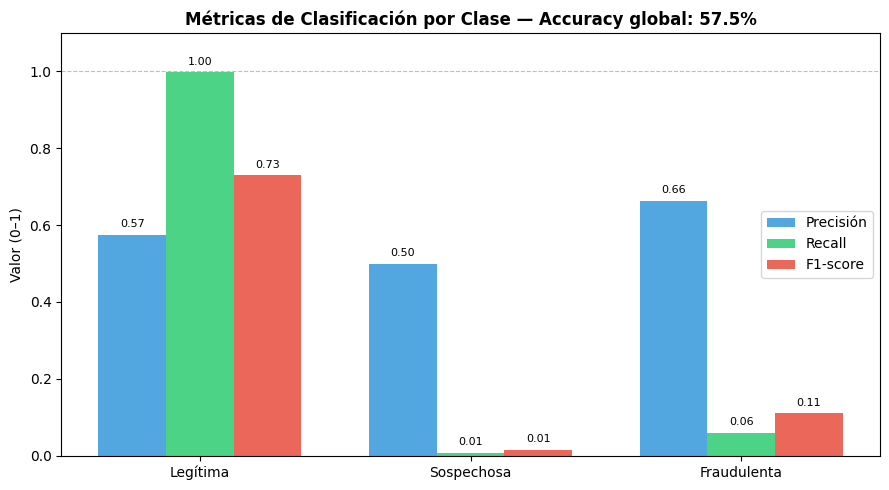

Gráfico guardado como 'hmm_fraude_metricas_clasif.png'


In [ ]:
etiquetas  = list(met_clasif.keys())
precisiones = [met_clasif[e]['precision'] for e in etiquetas]
recalls     = [met_clasif[e]['recall']    for e in etiquetas]
f1s         = [met_clasif[e]['f1']        for e in etiquetas]

x = np.arange(len(etiquetas))
ancho = 0.25

fig4, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - ancho, precisiones, ancho, label='Precisión', color='#3498db', alpha=0.85)
ax.bar(x,         recalls,     ancho, label='Recall',    color='#2ecc71', alpha=0.85)
ax.bar(x + ancho, f1s,         ancho, label='F1-score',  color='#e74c3c', alpha=0.85)

ax.set_title(f'Métricas de Clasificación por Clase — Accuracy global: {accuracy_vitb:.1f}%',
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(etiquetas)
ax.set_ylabel('Valor (0–1)')
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend()

for i, (p, r, f) in enumerate(zip(precisiones, recalls, f1s)):
    ax.text(i - ancho, p + 0.02, f'{p:.2f}', ha='center', fontsize=8)
    ax.text(i,         r + 0.02, f'{r:.2f}', ha='center', fontsize=8)
    ax.text(i + ancho, f + 0.02, f'{f:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('hmm_fraude_metricas_clasif.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado como 'hmm_fraude_metricas_clasif.png'")

## 10 · Resumen y conclusiones

### ¿Qué aprendimos?

| Componente | Rol en el modelo |
|---|---|
| **π (distribución inicial)** | El 70% de las transacciones empieza siendo legítima — refleja un sistema real |
| **Matriz A (transición)** | El fraude tiene 60% de persistir → los patrones fraudulentos son continuos |
| **Matriz B (emisión)** | El fraude emite montos altos con 60% → señal observable clave |
| **Viterbi** | Decodifica la secuencia más probable sin ver los estados reales |
| **Score de riesgo** | Traduce el estado inferido en un número accionable (0–100) |

### Limitaciones del modelo
- Las matrices A y B fueron **definidas manualmente** — en un sistema real se aprenderían con el **algoritmo de Baum-Welch**
- Solo hay **3 categorías de monto** — un modelo real usaría distribuciones continuas (Gaussianas)
- La simulación es con **50 transacciones** — en producción se trabajaría con millones